In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

np.random.seed(42)

Matplotlib is building the font cache; this may take a moment.


# Lab 0 Exercises: Python for AI Foundations

Name: Deborah Maame Araba Koufie 
Course: Introduction to Artificial Intelligence  

This notebook contains the graded Lab 0 exercises covering NumPy, Pandas, data visualization, and an integration challenge.

## Exercise 4: NumPy Array Operations

In this exercise, I use NumPy to create and manipulate arrays. The tasks include creating a border matrix, normalizing a random array, and calculating linear regression coefficients using the normal equation.

In [17]:
# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0

border_matrix = np.ones((5, 5))
border_matrix[1:-1, 1:-1] = 0

print("5x5 border matrix:")
print(border_matrix)

5x5 border matrix:
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]


### Task 2: Normalize a Random Array

This task creates a random 100x3 array and normalizes each column so that each column has a mean of 0 and a standard deviation of 1.

In [18]:
# Task 2: Normalize a random array

np.random.seed(42)
random_data = np.random.randn(100, 3)

column_means = random_data.mean(axis=0)
column_stds = random_data.std(axis=0)

normalized_data = (random_data - column_means) / column_stds

print("Original column means:")
print(column_means)

print("\nOriginal column standard deviations:")
print(column_stds)

print("\nMeans after normalization:")
print(normalized_data.mean(axis=0))

print("\nStandard deviations after normalization:")
print(normalized_data.std(axis=0))

Original column means:
[ 0.09176598 -0.18323331  0.07482166]

Original column standard deviations:
[0.82066472 0.97419224 1.10733139]

Means after normalization:
[-9.15933995e-17  1.11022302e-17 -8.88178420e-18]

Standard deviations after normalization:
[1. 1. 1.]


### Task 3: Linear Regression Using the Normal Equation

This task uses the normal equation to estimate linear regression coefficients and compares the estimated coefficients with the true coefficients.

In [19]:
# Task 3: Implement linear regression solution using the normal equation

X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("Estimated coefficients:")
print(theta_hat)

print("\nTrue coefficients:")
print(true_theta)

print("\nDifference between estimated and true coefficients:")
print(theta_hat - true_theta)

Estimated coefficients:
[ 2.51723721 -1.19783796  3.72399266]

True coefficients:
[ 2.5 -1.2  3.7]

Difference between estimated and true coefficients:
[0.01723721 0.00216204 0.02399266]


## Exercise 5: Pandas Data Analysis
analyzing a student performance dataset using Pandas. The tasks include data cleaning, handling missing values, calculating summary statistics, creating performance categories, and generating grouped summaries and pivot tables.

In [7]:
#Exercise 5: Pandas Data Analysis
# Step 1: Create the student performance dataset

import pandas as pd
import numpy as np
from IPython.display import display

np.random.seed(42)
n_students = 200

data = {
    "student_id": range(1000, 1000 + n_students),
    "major": np.random.choice(["CS", "Math", "Physics", "Biology"], n_students),
    "year": np.random.choice([1, 2, 3, 4], n_students),
    "exam_score": np.random.normal(75, 10, n_students).clip(0, 100),
    "assignments_completed": np.random.randint(0, 11, n_students),
    "hours_studied": np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce missing values
df.loc[np.random.choice(n_students, 10, replace=False), "exam_score"] = np.nan
df.loc[np.random.choice(n_students, 5, replace=False), "hours_studied"] = np.nan

print("First five rows of the dataset:")
display(df.head())

print("Dataset shape:")
print(df.shape)

First five rows of the dataset:


,student_id,major,year,exam_score,assignments_completed,hours_studied
0,1000,Physics,3,68.199753,10,NaN
1,1001,Biology,4,77.322537,9,12.204873
2,1002,CS,3,77.930725,9,7.829556
3,1003,Physics,1,67.856486,2,14.042336
4,1004,Physics,4,93.657745,6,15.287370


Dataset shape:
(200, 6)


### Task 1: Data Cleaning and Exploration



In [8]:
# Task 1: Data Cleaning and Exploration

print("Basic information about the dataset:")
df.info()

print("\nMissing values before cleaning:")
print(df.isnull().sum())

# Fill missing exam_score with the mean score for the student's major
df["exam_score"] = df.groupby("major")["exam_score"].transform(
    lambda x: x.fillna(x.mean())
)

# Fill missing hours_studied with the median hours studied for the student's year
df["hours_studied"] = df.groupby("year")["hours_studied"].transform(
    lambda x: x.fillna(x.median())
)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nStatistical summary after cleaning:")
display(df.describe())

Basic information about the dataset:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), str(1)
memory usage: 9.5 KB

Missing values before cleaning:
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64

Missing values after cleaning:
student_id               0
major                    0
year                     0
exam_score               0
assignments_completed    0
hours_studied  

,student_id,year,exam_score,assignments_completed,hours_studied
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,1099.500000,2.615000,75.510735,4.700000,14.804057
std,57.879185,1.159091,9.218768,3.239207,5.142305
min,1000.000000,1.000000,42.587327,0.000000,1.295226
25%,1049.750000,2.000000,68.479674,2.000000,11.869371
50%,1099.500000,3.000000,75.769770,4.000000,14.519557
75%,1149.250000,4.000000,81.382871,8.000000,17.998705
max,1199.000000,4.000000,100.000000,10.000000,28.918887


### Task 2: Analysis

This task calculates the average exam score by major, identifies the major with the highest average score, checks the correlation between hours studied and exam score, and creates a performance category for each student.

In [9]:
# Task 2: Analysis

# Calculate average exam_score by major
average_score_by_major = df.groupby("major")["exam_score"].mean().sort_values(ascending=False)

print("Average exam score by major:")
display(average_score_by_major)

# Find the major with the highest average exam_score
highest_major = average_score_by_major.idxmax()
highest_average = average_score_by_major.max()

print(f"\nMajor with the highest average exam score: {highest_major}")
print(f"Highest average exam score: {highest_average:.2f}")

# Calculate the correlation between hours_studied and exam_score
correlation = df["hours_studied"].corr(df["exam_score"])

print(f"\nCorrelation between hours studied and exam score: {correlation:.3f}")

# Create a new performance column
conditions = [
    df["exam_score"] > 90,
    (df["exam_score"] >= 80) & (df["exam_score"] <= 90),
    (df["exam_score"] >= 70) & (df["exam_score"] < 80),
    df["exam_score"] < 70
]

categories = ["Excellent", "Good", "Average", "Needs Improvement"]

df["performance"] = np.select(conditions, categories, default="Uncategorized")

print("\nPerformance category counts:")
display(df["performance"].value_counts())

print("\nFirst five rows with the new performance column:")
display(df.head())

Average exam score by major:


major
Biology    75.877440
CS         75.781493
Physics    75.333242
Math       75.017860
Name: exam_score, dtype: float64


Major with the highest average exam score: Biology
Highest average exam score: 75.88

Correlation between hours studied and exam score: -0.020

Performance category counts:


performance
Average              79
Needs Improvement    58
Good                 52
Excellent            11
Name: count, dtype: int64


First five rows with the new performance column:


,student_id,major,year,exam_score,assignments_completed,hours_studied,performance
0,1000,Physics,3,68.199753,10,14.031175,Needs Improvement
1,1001,Biology,4,77.322537,9,12.204873,Average
2,1002,CS,3,77.930725,9,7.829556,Average
3,1003,Physics,1,67.856486,2,14.042336,Needs Improvement
4,1004,Physics,4,93.657745,6,15.287370,Excellent


### Task 3: Advanced Analysis

This task groups the data by major and year, calculates summary statistics, identifies the top students based on exam score while handling ties, and creates a pivot table of average exam scores.

In [10]:
# Task 3: Advanced Analysis

# For each major and year combination, calculate:
# - number of students
# - average exam score
# - average hours studied

major_year_summary = df.groupby(["major", "year"]).agg(
    number_of_students=("student_id", "count"),
    average_exam_score=("exam_score", "mean"),
    average_hours_studied=("hours_studied", "mean")
).round(2)

print("Summary by major and year:")
display(major_year_summary)


# Identify top 5 students based on exam_score and handle ties appropriately
df["exam_rank"] = df["exam_score"].rank(method="min", ascending=False)

top_students = df[df["exam_rank"] <= 5].sort_values(
    by=["exam_score", "student_id"],
    ascending=[False, True]
)

print("\nTop 5 students based on exam score, including ties:")
display(top_students[["student_id", "major", "year", "exam_score", "exam_rank"]])


# Create a pivot table showing average exam_score by major and year
pivot_table = pd.pivot_table(
    df,
    values="exam_score",
    index="major",
    columns="year",
    aggfunc="mean"
).round(2)

print("\nPivot table showing average exam score by major and year:")
display(pivot_table)


Summary by major and year:


number_of_students  average_exam_score  average_hours_studied
major   year                                                               
Biology 1                     13               77.25                  12.68
        2                     12               74.45                  13.43
        3                     14               80.29                  15.10
        4                     15               71.71                  14.64
CS      1                     12               74.63                  13.64
        2                      7               76.16                  13.60
        3                      9               72.35                  15.04
        4                     18               78.12                  16.28
Math    1                     11               74.55                  18.22
        2                      9               83.20                  12.65
        3                     10               72.02                  15.18
        4                     16               72.61                  17.32
Physics 1                     13               76.72                  13.49
        2                     12               73.28                  14.62
        3                     17               73.06                  13.91
        4                     12               79.11                  15.55


Top 5 students based on exam score, including ties:


,student_id,major,year,exam_score,exam_rank
27,1027,Math,2,100.000000,1.0
57,1057,CS,2,100.000000,1.0
68,1068,Biology,3,98.146586,3.0
82,1082,CS,2,96.439441,4.0
132,1132,CS,4,96.330334,5.0



Pivot table showing average exam score by major and year:


year,1,2,3,4
major,,,,
Biology,77.25,74.45,80.29,71.71
CS,74.63,76.16,72.35,78.12
Math,74.55,83.20,72.02,72.61
Physics,76.72,73.28,73.06,79.11


## Exercise 6: Data Visualization

In this exercise, I create visualizations using the student performance dataset from Exercise 5. The visualizations show exam score distributions, relationships between study time and exam performance, and summary patterns across majors, years, and performance categories.

### Task 1: Distribution Visualization

This task creates two plots: a histogram showing the distribution of exam scores and a box plot comparing exam scores across majors.

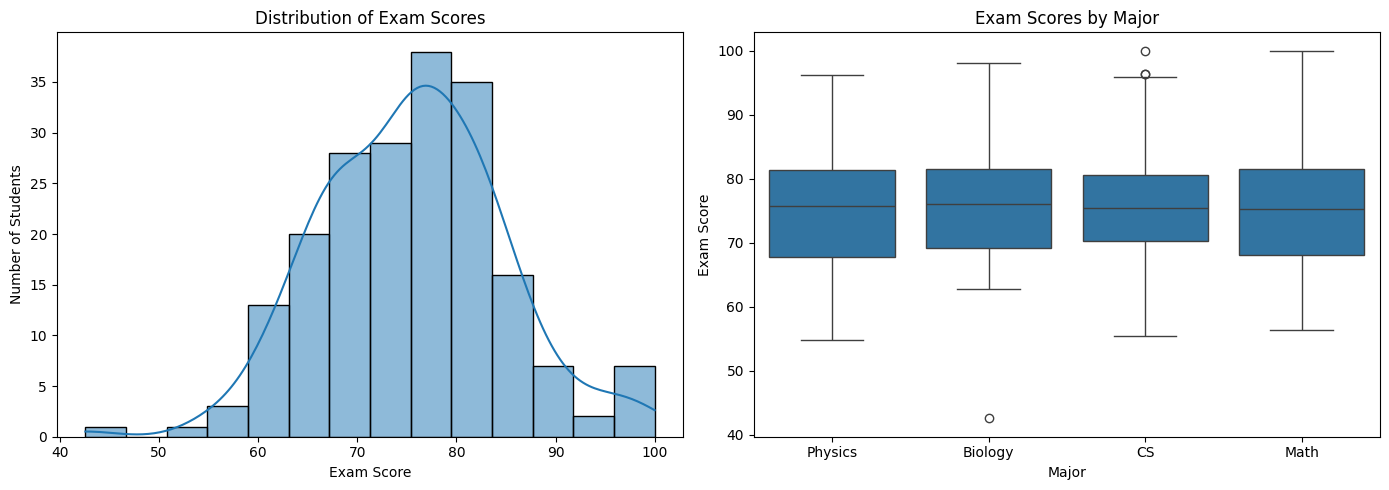

In [11]:
# Task 1: Distribution Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Histogram of exam scores with KDE overlay
sns.histplot(data=df, x="exam_score", kde=True, ax=axes[0])
axes[0].set_title("Distribution of Exam Scores")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Number of Students")

# Right plot: Box plot of exam scores by major
sns.boxplot(data=df, x="major", y="exam_score", ax=axes[1])
axes[1].set_title("Exam Scores by Major")
axes[1].set_xlabel("Major")
axes[1].set_ylabel("Exam Score")

plt.tight_layout()
plt.show()

### Task 2: Relationship Visualization

This task creates a scatter plot of hours studied against exam score. The points are colored by major, and a regression line is added to show the overall relationship.

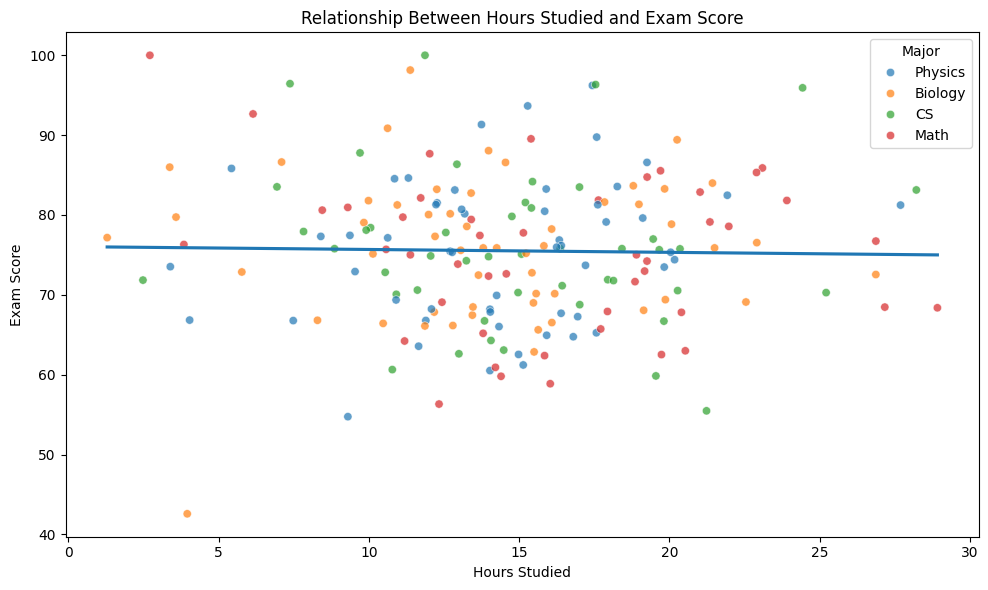

In [12]:
# Task 2: Relationship Visualization

plt.figure(figsize=(10, 6))

# Scatter plot colored by major
sns.scatterplot(
    data=df,
    x="hours_studied",
    y="exam_score",
    hue="major",
    alpha=0.7
)

# Regression line showing the overall trend
sns.regplot(
    data=df,
    x="hours_studied",
    y="exam_score",
    scatter=False,
    ci=None
)

plt.title("Relationship Between Hours Studied and Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend(title="Major")
plt.tight_layout()
plt.show()

### Task 3: Advanced Dashboard

This task creates a 2x2 dashboard containing a bar chart, count plot, correlation heatmap, and violin plot.

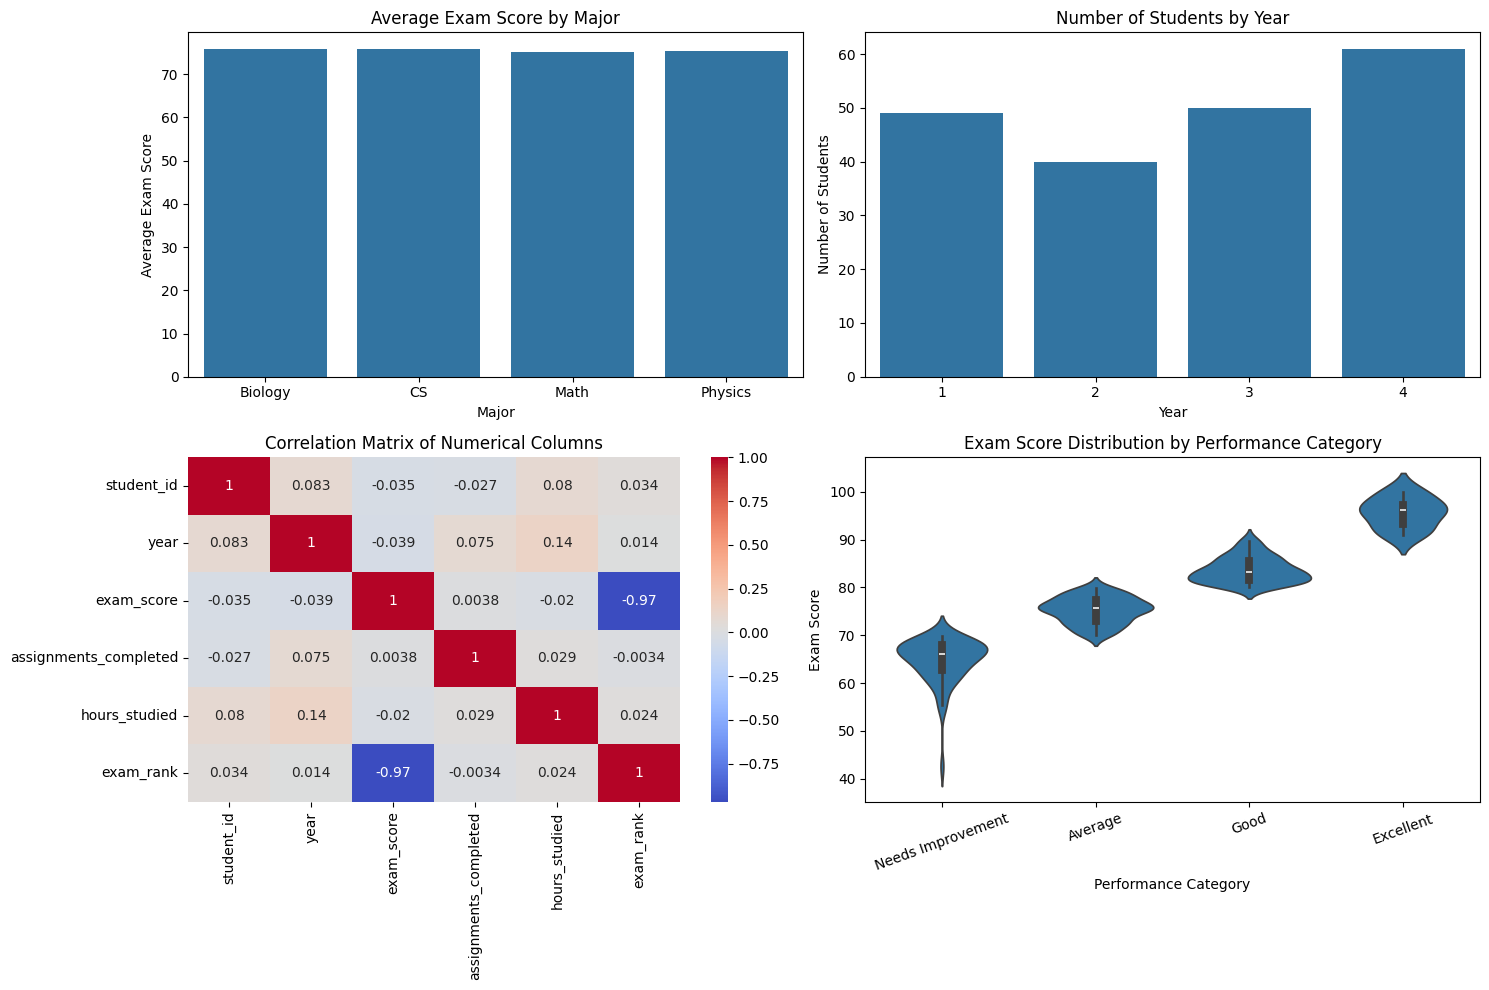

In [13]:
# Task 3: Advanced Dashboard

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Bar chart: Average exam score by major
average_scores = df.groupby("major")["exam_score"].mean().reset_index()

sns.barplot(
    data=average_scores,
    x="major",
    y="exam_score",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Average Exam Score by Major")
axes[0, 0].set_xlabel("Major")
axes[0, 0].set_ylabel("Average Exam Score")

# 2. Count plot: Number of students by year
sns.countplot(
    data=df,
    x="year",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Number of Students by Year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Number of Students")

# 3. Heat map: Correlation matrix of numerical columns
numeric_df = df.select_dtypes(include="number")
correlation_matrix = numeric_df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Correlation Matrix of Numerical Columns")

# 4. Violin plot: Exam score distribution by performance category
performance_order = ["Needs Improvement", "Average", "Good", "Excellent"]

sns.violinplot(
    data=df,
    x="performance",
    y="exam_score",
    order=performance_order,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Exam Score Distribution by Performance Category")
axes[1, 1].set_xlabel("Performance Category")
axes[1, 1].set_ylabel("Exam Score")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Exercise 7: Integration Challenge

In this exercise, I analyze synthetic customer data for an e-commerce company. I calculate customer lifetime value, group customers by age, identify high-value customers, create visualizations, and summarize key findings.

In [ ]:

# Step 1: Generate synthetic e-commerce customer data

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    "age": ages,
    "income": income,
    "purchase_frequency": purchase_freq,
    "avg_purchase_value": avg_purchase_value
})

# Calculate churn risk
max_frequency = customers["purchase_frequency"].max()
customers["churn_risk"] = 1 - (customers["purchase_frequency"] / max_frequency)

# Calculate customer lifetime value
customers["CLV"] = (
    customers["purchase_frequency"]
    * customers["avg_purchase_value"]
    * (1 + customers["churn_risk"])
)

print("First five rows of customer data:")
display(customers.head())

print("\nDataset shape:")
print(customers.shape)

First five rows of customer data:


,age,income,purchase_frequency,avg_purchase_value,churn_risk,CLV
0,56,92443.123940,7,94.527456,0.416667,937.397271
1,69,70649.305211,2,100.932279,0.833333,370.085023
2,46,19612.600681,3,79.699876,0.750000,418.424348
3,32,40315.318543,2,130.137787,0.833333,477.171887
4,60,75338.222984,8,102.904845,0.333333,1097.651683



Dataset shape:
(500, 6)


### Customer Segmentation and Summary Statistics

This section creates customer age groups, calculates summary statistics for each group, and identifies the top 10% of customers based on customer lifetime value.

In [15]:
# Step 2: Create age groups and summarize customer data

customers["age_group"] = pd.cut(
    customers["age"],
    bins=[17, 25, 35, 50, 70],
    labels=["18-25", "26-35", "36-50", "51-70"]
)

age_group_summary = customers.groupby("age_group", observed=False).agg(
    number_of_customers=("age", "count"),
    average_income=("income", "mean"),
    average_CLV=("CLV", "mean"),
    total_CLV=("CLV", "sum")
).round(2)

print("Summary by age group:")
display(age_group_summary)

# Identify top 10% of customers by CLV
clv_threshold = customers["CLV"].quantile(0.90)

top_10_percent_customers = customers[customers["CLV"] >= clv_threshold].sort_values(
    by="CLV",
    ascending=False
)

print(f"\nCLV threshold for top 10% customers: {clv_threshold:.2f}")
print(f"Number of top 10% customers: {len(top_10_percent_customers)}")

print("\nTop 10 customers by CLV:")
display(top_10_percent_customers.head(10))

Summary by age group:


,number_of_customers,average_income,average_CLV,total_CLV
age_group,,,,
18-25,81,50634.02,718.37,58188.06
26-35,73,48747.15,747.74,54584.92
36-50,160,48516.90,732.80,117247.46
51-70,186,50713.16,762.69,141860.99



CLV threshold for top 10% customers: 1222.94
Number of top 10% customers: 50

Top 10 customers by CLV:


,age,income,purchase_frequency,avg_purchase_value,churn_risk,CLV,age_group
426,42,68713.567863,8,154.285448,0.333333,1645.711441,36-50
213,41,45580.608009,7,164.920221,0.416667,1635.458860,36-50
410,44,49344.934596,6,177.097211,0.500000,1593.874900,36-50
194,44,57331.964922,6,176.640590,0.500000,1589.765308,36-50
244,28,29255.076913,7,159.784979,0.416667,1584.534373,26-35
423,43,34443.666248,6,173.245130,0.500000,1559.206172,36-50
386,63,24200.782005,9,136.030443,0.250000,1530.342482,51-70
187,47,48889.046022,8,143.183371,0.333333,1527.289296,36-50
361,38,27490.219054,7,153.105028,0.416667,1518.291532,36-50
180,62,44611.863311,7,151.961479,0.416667,1506.951331,51-70


### Customer Data Visualizations

This section creates a scatter plot of income against CLV, a bar chart of average CLV by age group, and a correlation heatmap.

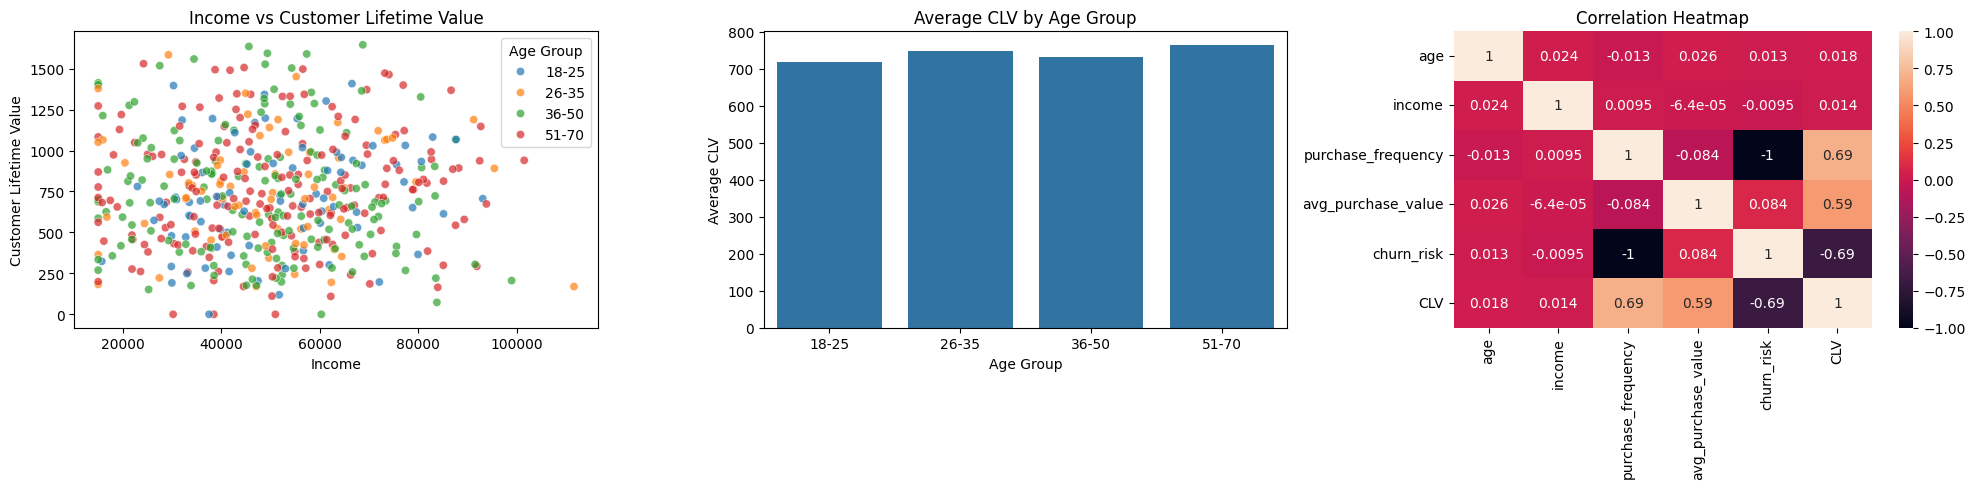

In [16]:
# Step 3: Create visualizations

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Scatter plot of income vs CLV, colored by age group
sns.scatterplot(
    data=customers,
    x="income",
    y="CLV",
    hue="age_group",
    alpha=0.7,
    ax=axes[0]
)

axes[0].set_title("Income vs Customer Lifetime Value")
axes[0].set_xlabel("Income")
axes[0].set_ylabel("Customer Lifetime Value")
axes[0].legend(title="Age Group")

# 2. Bar chart of average CLV by age group
average_clv_by_age = customers.groupby("age_group", observed=False)["CLV"].mean().reset_index()

sns.barplot(
    data=average_clv_by_age,
    x="age_group",
    y="CLV",
    ax=axes[1]
)

axes[1].set_title("Average CLV by Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Average CLV")

# 3. Correlation heatmap
numeric_customers = customers.select_dtypes(include="number")
customer_correlation = numeric_customers.corr()

sns.heatmap(
    customer_correlation,
    annot=True,
    ax=axes[2]
)

axes[2].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

### Brief Analysis and Recommendations

The analysis shows differences in customer lifetime value across age groups. The age group with the highest average CLV represents an important customer segment because these customers generate more value on average. The top 10% of customers by CLV should be prioritized for loyalty programs, personalized offers, and retention campaigns. The scatter plot also helps show whether income is strongly related to CLV, while the heatmap highlights the strongest relationships among numerical variables. Overall, the company should focus on retaining high-CLV customers and studying the purchasing behavior of the most valuable age groups.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)